In [1]:
import joblib
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.decomposition import FastICA
from utils import load_images
import joblib
import pathlib
from pathlib import Path

/usr/local/lib/python3.8/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Load all 9 ICA models and images

In [2]:
basepath = Path("/src/project/data/ica/repeat_9_crop_12_comp_40")

model_list = []
for entry in basepath.iterdir():
    # go through files and load joblib files
    if entry.is_file() and entry.suffix == ".joblib":
        model = joblib.load(entry)
        model_list.append(model)

print(model_list)

images = load_images(crop_size=36)
print("loaded images shape", images.shape)

[FastICA(n_components=40, random_state=752767290, whiten='unit-variance'), FastICA(n_components=40, random_state=3653403230, whiten='unit-variance'), FastICA(n_components=40, random_state=70985653, whiten='unit-variance'), FastICA(n_components=40, random_state=323153948, whiten='unit-variance'), FastICA(n_components=40, random_state=1322117303, whiten='unit-variance'), FastICA(n_components=40, random_state=2195314464, whiten='unit-variance'), FastICA(n_components=40, random_state=2735729614, whiten='unit-variance'), FastICA(n_components=40, random_state=175979944, whiten='unit-variance'), FastICA(n_components=40, random_state=1158725111, whiten='unit-variance')]
loaded images shape (20000, 36, 36)


### Reshape the (B, 36, 36) images to (B, 9, 12, 12) image crops

In [3]:
image_patches = images.reshape(20000, 3, 12, 3, 12).transpose(0, 1, 3, 2, 4).reshape(20000, 9, 12, 12)
print(image_patches.shape)

(20000, 9, 12, 12)


### Check an arbitrary image and correspondingly the 9 12x12 crops to ensure cropping is correct

(-0.5, 35.5, 35.5, -0.5)

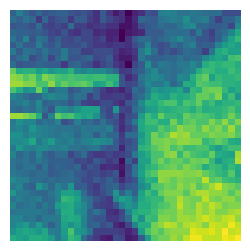

In [4]:
image_idx = 43
single_full_image = images[image_idx]
fig, ax = plt.subplots(dpi=100, figsize=(3, 3))
ax.imshow(single_full_image)
ax.axis("off")

In [45]:
image_patches.shape

(20000, 9, 12, 12)

(-0.5, 35.5, 35.5, -0.5)

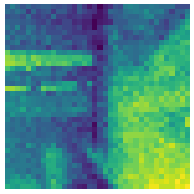

In [49]:
fig, ax = plt.subplots(dpi=50)
ax.imshow(np.vstack([np.hstack(single_image_patches[i * 3 : (i + 1) * 3]) for i in range(3)]))
ax.axis("off")

### On each of these 9 12x12 crops, run the 9 ICA models and get the 9 40-dim ICA activations

In [6]:
# first transpose the image patches such that it's (9, B, 12, 12) instead of (B, 9, 12, 12)
# then reshape to (9, B, 144)
image_patches_for_ica = image_patches.transpose(1, 0, 2, 3).reshape(9, 20000, 144)
print(image_patches_for_ica.shape)

(9, 20000, 144)


In [7]:
zs = []
for patch, model in zip(image_patches_for_ica, model_list):
    z = model.transform(patch)
    zs.append(z)
zs = np.array(zs)
print(zs.shape)

(9, 20000, 40)


### Learn an ICA model again on these 9x40-dim ICA activations

In [8]:
zs_flattened = zs.transpose(1, 0, 2).reshape(20000, -1)
print(zs_flattened.shape)

(20000, 360)


In [57]:
layer2_latent_sizes = [i for i in range(1, 41) if i % 4 == 0]
layer2_latent_sizes.insert(0, 2)

In [58]:
layer2_latent_sizes

[2, 4, 8, 12, 16, 20, 24, 28, 32, 36, 40]

In [9]:
n_components = 2
ica_model = FastICA(n_components=n_components, fun="logcosh", max_iter=1000, whiten=True, random_state=42)
ica_model.fit(zs_flattened)

/usr/local/lib/python3.8/dist-packages/sklearn/decomposition/_fastica.py:729: FutureWarning: Starting in v1.3, whiten=True should be specified as whiten='arbitrary-variance' (its current behaviour). This behavior is deprecated in 1.1 and will raise ValueError in 1.3.
  self._fit_transform(X, compute_sources=False)


FastICA(max_iter=1000, n_components=2, random_state=42, whiten=True)

In [10]:
ica_model.components_.shape

(2, 360)

### How to make sense of the second level ICA model?

### One-hot encode the 9x40-dim ICA activations and visualize the generated images

In [36]:
one_hot_gs = np.zeros(n_components) 
one_hot_gs[0] = 1
one_hot_gs = one_hot_gs.reshape(1, -1)
print(one_hot_gs.shape)

(1, 2)


In [37]:
edge_img = ica_model.inverse_transform(one_hot_gs)
edge_img.shape

(1, 360)

In [38]:
edge_img_reshaped = edge_img.reshape(1, 9, 40).transpose(1, 0, 2)
print(edge_img_reshaped.shape)

(9, 1, 40)


In [39]:
gen_image_patches = []
for edge_img_sample, model in zip(edge_img_reshaped, model_list):
    gen_image_patch = model.inverse_transform(edge_img_sample)
    gen_image_patches.append(gen_image_patch)
gen_image_patches = np.array(gen_image_patches)

In [40]:
gen_image_patches.shape

(9, 1, 144)

In [41]:
gen_image_patches = gen_image_patches.squeeze(1)

In [42]:
print(gen_image_patches.shape)

(9, 144)


In [43]:
gen_image_patches = gen_image_patches.reshape(9, 12, 12)

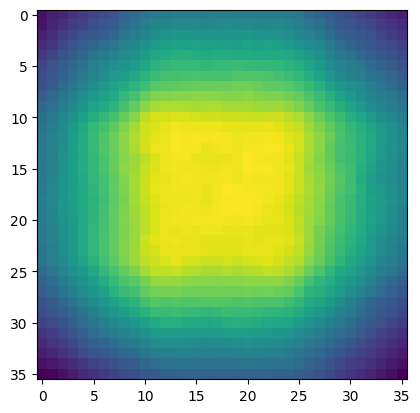

In [44]:
plt.imshow(np.vstack([np.hstack(gen_image_patches[i * 3 : (i + 1) * 3]) for i in range(3)]))

In [93]:
layer3_sizes = [i for i in range(1, 100) if i % 4 == 0]
layer3_sizes.insert(0, 2)
print(layer3_sizes)

[2, 4, 8, 12, 16, 20, 24, 28, 32, 36, 40, 44, 48, 52, 56, 60, 64, 68, 72, 76, 80, 84, 88, 92, 96]


In [94]:
all_images = []
for layer3_size in layer3_sizes:
    ica_layer3_model = FastICA(
        n_components=layer3_size,
        whiten="unit-variance",
        random_state=42,
    )
    ica_layer3_model.fit(zs_flattened)
    hot_id_images = []
    for hot_idx in range(layer3_size):
        one_hot_g = np.zeros(layer3_size)
        one_hot_g[hot_idx] = 1
        one_hot_g = one_hot_g.reshape(1, -1)
        layer2_img = ica_layer3_model.inverse_transform(one_hot_g)
        layer2_img_reshaped = layer2_img.reshape(1, 9, 40).transpose(1, 0, 2)
        gen_image_patches = []
        for layer2_img_sample, model in zip(layer2_img_reshaped, model_list):
            gen_image_patch = model.inverse_transform(layer2_img_sample)
            gen_image_patch = gen_image_patch.squeeze(0)
            gen_image_patches.append(gen_image_patch)
        gen_image_patches = np.array(gen_image_patches)
        hot_id_images.append(gen_image_patches)
    hot_id_images = np.array(hot_id_images)
    hot_id_images = hot_id_images.reshape(hot_id_images.shape[0], 9, 12, 12)
    stacked_images = []
    for img in hot_id_images:
        stacked_hot_id_images = np.vstack([np.hstack(img[i * 3 : (i + 1) * 3]) for i in range(3)])
        stacked_images.append(stacked_hot_id_images)
    stacked_images = np.array(stacked_images)
    all_images.append(stacked_images)

In [95]:
stacked_images.shape

(96, 36, 36)

In [96]:
all_images[0].shape, all_images[1].shape, all_images[-1].shape

((2, 36, 36), (4, 36, 36), (96, 36, 36))

In [97]:
layer3_sizes

[2,
 4,
 8,
 12,
 16,
 20,
 24,
 28,
 32,
 36,
 40,
 44,
 48,
 52,
 56,
 60,
 64,
 68,
 72,
 76,
 80,
 84,
 88,
 92,
 96]

In [98]:
fig, axs = plt.subplots(nrows=len(layer3_sizes), ncols=layer3_sizes[-1], figsize=(2*layer3_sizes[-1], 2*len(layer3_sizes)))
for i in range(len(layer3_sizes)):
    for j in range(layer3_sizes[-1]):
        if j < layer3_sizes[i]:
            axs[i, j].imshow(all_images[i][j])
        axs[i, j].axis("off")